<a href="https://colab.research.google.com/github/nulahaa-cpu/AIFFEL_quest_cr/blob/main/Exploration/Ex03/colab_augmentation_stanford_dogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐶 Stanford Dogs — Augmentation 비교 (Colab / PyTorch / ResNet-50)

**No Aug / Basic Aug / Basic+Mixup / Basic+CutMix** 4가지를 학습하고
훈련 히스토리 시각화 + 견종 분류 정확도를 비교·분석합니다.

### ▶ 사용법 (그냥 위에서부터 차례로 실행하면 됩니다)
1. 상단 메뉴 **런타임 → 런타임 유형 변경 → 하드웨어 가속기: GPU (T4)** 선택
2. **런타임 → 모두 실행** (Ctrl+F9)

> 데이터셋(약 750MB)은 첫 셀에서 자동 다운로드됩니다.
> Colab 무료 GPU로도 돌도록 기본값은 **클래스 일부만(`USE_SUBSET`) + 적은 epoch** 으로 설정돼 있어요.
> 전체 120견종으로 돌리려면 아래 설정 셀에서 `USE_SUBSET = None` 으로 바꾸세요.


## 0. GPU 확인

In [1]:
!nvidia-smi -L || echo '⚠️ GPU 미할당: 런타임 → 런타임 유형 변경 → GPU 선택 후 다시 실행하세요.'

GPU 0: Tesla T4 (UUID: GPU-abb0c72c-5b69-b028-888a-0c187cf77bd5)


## 1. 데이터셋 다운로드 (Stanford Dogs)

공식 배포본(`images.tar`)을 받아 압축을 풀면 `Images/` 아래에 견종별 폴더가 생겨
바로 `ImageFolder` 로 사용할 수 있습니다.


In [2]:
import os, urllib.request, tarfile, time

DATA_ROOT  = "/content/stanford_dogs"
IMAGES_DIR = os.path.join(DATA_ROOT, "Images")
TAR_PATH   = os.path.join(DATA_ROOT, "images.tar")
URL        = "http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar"

os.makedirs(DATA_ROOT, exist_ok=True)
if not os.path.isdir(IMAGES_DIR):
    if not os.path.exists(TAR_PATH):
        print("다운로드 중... (약 750MB, 수 분 소요)")
        t0 = time.time()
        urllib.request.urlretrieve(URL, TAR_PATH)
        print(f"완료: {time.time()-t0:.0f}s")
    print("압축 해제 중...")
    with tarfile.open(TAR_PATH) as tar:
        tar.extractall(DATA_ROOT)
    print("완료")
else:
    print("이미 준비됨")

classes = sorted(os.listdir(IMAGES_DIR))
print("견종(클래스) 수:", len(classes))
print("예시:", classes[:3])


다운로드 중... (약 750MB, 수 분 소요)
완료: 70s
압축 해제 중...


/tmp/ipykernel_3497/3502873263.py:17: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_ROOT)


완료
견종(클래스) 수: 120
예시: ['n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog']


## 2. 임포트 & 디바이스

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import DataLoader, random_split

torch.manual_seed(42); np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


## 3. 실행 설정 (여기서 규모 조절)

- `USE_SUBSET`: 빠른 실행용으로 앞에서 N개 견종만 사용. 전체로 돌리려면 `None`.
- 무료 T4 기준 권장: 20견종 / 5 epoch 정도면 4개 실험이 수십 분 내에 끝납니다.


In [4]:
USE_SUBSET = 20      # 사용할 견종 수 (전체 120종이면 None)
BATCH_SIZE = 32
EPOCHS     = 5
LR         = 1e-4

# 서브셋이면 클래스 일부만 담은 임시 디렉터리를 심볼릭 링크로 구성
if USE_SUBSET is not None:
    SUBSET_DIR = "/content/dogs_subset"
    os.makedirs(SUBSET_DIR, exist_ok=True)
    for c in classes[:USE_SUBSET]:
        link = os.path.join(SUBSET_DIR, c)
        if not os.path.exists(link):
            os.symlink(os.path.join(IMAGES_DIR, c), link)
    DATASET_DIR = SUBSET_DIR
else:
    DATASET_DIR = IMAGES_DIR

print("DATASET_DIR =", DATASET_DIR)
print("사용 클래스 수:", len(os.listdir(DATASET_DIR)))


DATASET_DIR = /content/dogs_subset
사용 클래스 수: 20


## 4. 데이터 파이프라인

기본/무 augmentation은 **레이블이 정수 그대로**, Mixup/CutMix는 두 이미지를 섞으므로
**레이블도 섞인 soft label**이 됩니다. (아래 mix 함수에서 처리)


In [5]:
def get_transform(mode="no_aug"):
    if mode == "basic_aug":
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
        ])
    else:  # no_aug
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
        ])


def build_dataloaders(dataset_dir, batch_size=32, aug_mode="no_aug"):
    base_dataset = ImageFolder(dataset_dir, transform=None)
    train_size = int(0.8 * len(base_dataset))
    test_size  = len(base_dataset) - train_size
    train_indices, test_indices = random_split(
        range(len(base_dataset)), [train_size, test_size],
        generator=torch.Generator().manual_seed(42))   # split 고정 → 공정 비교

    train_dataset = torch.utils.data.Subset(
        ImageFolder(dataset_dir, transform=get_transform(aug_mode)),
        train_indices.indices)
    test_dataset = torch.utils.data.Subset(
        ImageFolder(dataset_dir, transform=get_transform("no_aug")),
        test_indices.indices)

    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                              shuffle=True, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size,
                              shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, test_loader, base_dataset


## 5. Mixup / CutMix (배치 단위, soft label)

In [6]:
def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1.0 - lam) * x[index]
    return mixed_x, y, y[index], lam


def rand_bbox(size, lam):
    H, W = size[2], size[3]
    cut_rat = np.sqrt(1.0 - lam)
    cut_h, cut_w = int(H * cut_rat), int(W * cut_rat)
    cy, cx = np.random.randint(H), np.random.randint(W)
    y1, y2 = np.clip(cy - cut_h//2, 0, H), np.clip(cy + cut_h//2, 0, H)
    x1, x2 = np.clip(cx - cut_w//2, 0, W), np.clip(cx + cut_w//2, 0, W)
    return x1, y1, x2, y2


def cutmix_data(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0), device=x.device)
    x = x.clone()
    x1, y1, x2, y2 = rand_bbox(x.size(), lam)
    x[:, :, y1:y2, x1:x2] = x[index, :, y1:y2, x1:x2]
    lam = 1.0 - ((x2 - x1) * (y2 - y1) / (x.size(-1) * x.size(-2)))  # 면적 보정
    return x, y, y[index], lam


# 정수 레이블 두 개에 대한 lam 가중 CrossEntropy (= soft label 학습과 동일)
def mix_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1.0 - lam) * criterion(pred, y_b)


## 6. 모델 훈련 — ResNet-50

In [7]:
def build_model(num_classes):
    model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)


def train_one_epoch(model, loader, criterion, optimizer, mix_mode=None):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        if mix_mode == "mixup":
            images, y_a, y_b, lam = mixup_data(images, labels, alpha=0.2)
            outputs = model(images)
            loss = mix_criterion(criterion, outputs, y_a, y_b, lam)
        elif mix_mode == "cutmix":
            images, y_a, y_b, lam = cutmix_data(images, labels, alpha=1.0)
            outputs = model(images)
            loss = mix_criterion(criterion, outputs, y_a, y_b, lam)
        else:  # 기본/무 augmentation: 레이블 정수 그대로
            outputs = model(images)
            loss = criterion(outputs, labels)

        loss.backward(); optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        running_loss += criterion(outputs, labels).item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


def run_experiment(name, train_loader, test_loader, num_classes,
                   mix_mode=None, epochs=5, lr=1e-4):
    print(f"\n===== [{name}] mix_mode={mix_mode} =====")
    model = build_model(num_classes)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for ep in range(epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion,
                                          optimizer, mix_mode=mix_mode)
        va_loss, va_acc = evaluate(model, test_loader, criterion)
        hist["train_loss"].append(tr_loss); hist["train_acc"].append(tr_acc)
        hist["val_loss"].append(va_loss);   hist["val_acc"].append(va_acc)
        print(f"[{name}] {ep+1}/{epochs} "
              f"train_loss={tr_loss:.4f} val_loss={va_loss:.4f} val_acc={va_acc:.4f}")
    return model, hist


### 4가지 실험 실행

In [8]:
train_no,    test_loader, base_dataset = build_dataloaders(DATASET_DIR, BATCH_SIZE, "no_aug")
train_basic, _, _ = build_dataloaders(DATASET_DIR, BATCH_SIZE, "basic_aug")
num_classes = len(base_dataset.classes)
print("클래스 수:", num_classes, "| 전체 샘플:", len(base_dataset))

histories = {}
_, histories["No Aug"]       = run_experiment("No Aug",      train_no,    test_loader, num_classes, mix_mode=None,     epochs=EPOCHS, lr=LR)
_, histories["Basic Aug"]    = run_experiment("Basic Aug",   train_basic, test_loader, num_classes, mix_mode=None,     epochs=EPOCHS, lr=LR)
_, histories["Basic+Mixup"]  = run_experiment("Basic+Mixup", train_basic, test_loader, num_classes, mix_mode="mixup",  epochs=EPOCHS, lr=LR)
_, histories["Basic+CutMix"] = run_experiment("Basic+CutMix",train_basic, test_loader, num_classes, mix_mode="cutmix", epochs=EPOCHS, lr=LR)


클래스 수: 20 | 전체 샘플: 3633

===== [No Aug] mix_mode=None =====
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 151MB/s]


[No Aug] 1/5 train_loss=1.5045 val_loss=0.3855 val_acc=0.8968
[No Aug] 2/5 train_loss=0.2774 val_loss=0.3701 val_acc=0.8817
[No Aug] 3/5 train_loss=0.0996 val_loss=0.3342 val_acc=0.9065
[No Aug] 4/5 train_loss=0.0623 val_loss=0.3695 val_acc=0.8927
[No Aug] 5/5 train_loss=0.0421 val_loss=0.3738 val_acc=0.8886

===== [Basic Aug] mix_mode=None =====
[Basic Aug] 1/5 train_loss=1.5057 val_loss=0.4012 val_acc=0.8790
[Basic Aug] 2/5 train_loss=0.3049 val_loss=0.3018 val_acc=0.9092
[Basic Aug] 3/5 train_loss=0.1668 val_loss=0.3164 val_acc=0.8955
[Basic Aug] 4/5 train_loss=0.1000 val_loss=0.3230 val_acc=0.8996
[Basic Aug] 5/5 train_loss=0.0688 val_loss=0.3475 val_acc=0.8886

===== [Basic+Mixup] mix_mode=mixup =====
[Basic+Mixup] 1/5 train_loss=1.7286 val_loss=0.4605 val_acc=0.8845
[Basic+Mixup] 2/5 train_loss=0.8800 val_loss=0.3948 val_acc=0.8982
[Basic+Mixup] 3/5 train_loss=0.6126 val_loss=0.3685 val_acc=0.8955
[Basic+Mixup] 4/5 train_loss=0.5614 val_loss=0.3815 val_acc=0.9023
[Basic+Mixup] 5/

## 7. 훈련 과정 시각화

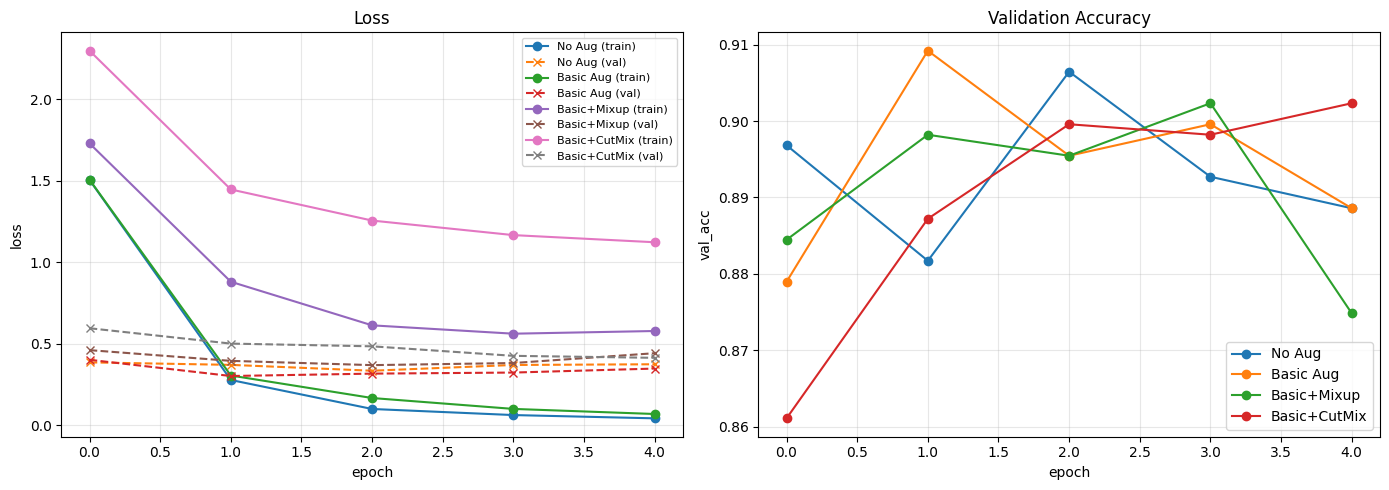

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, h in histories.items():
    axes[0].plot(h["train_loss"], marker="o", label=f"{name} (train)")
    axes[0].plot(h["val_loss"],   marker="x", linestyle="--", label=f"{name} (val)")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

for name, h in histories.items():
    axes[1].plot(h["val_acc"], marker="o", label=name)
axes[1].set_title("Validation Accuracy"); axes[1].set_xlabel("epoch")
axes[1].set_ylabel("val_acc"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 8. Augmentation 별 성능 비교

method          final val_acc   best val_acc
No Aug                 0.8886         0.9065
Basic Aug              0.8886         0.9092
Basic+Mixup            0.8748         0.9023
Basic+CutMix           0.9023         0.9023


/tmp/ipykernel_3497/1553491020.py:15: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3497/1553491020.py:15: UserWarning: Glyph 44204 (\N{HANGUL SYLLABLE GYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3497/1553491020.py:15: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3497/1553491020.py:15: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3497/1553491020.py:15: UserWarning: Glyph 47448 (\N{HANGUL SYLLABLE RYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3497/1553491020.py:15: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3497/1553491020.py:15: UserWarning: Glyph 

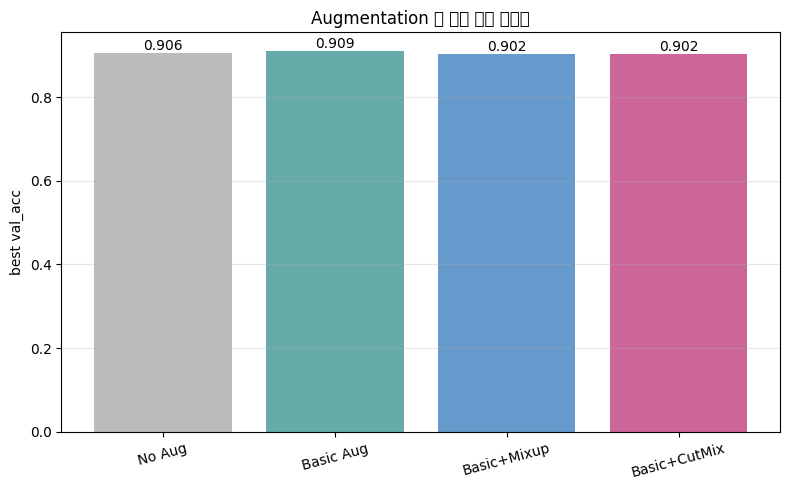

In [10]:
names = list(histories.keys())
final_acc = [histories[n]["val_acc"][-1]  for n in names]
best_acc  = [max(histories[n]["val_acc"]) for n in names]

print(f"{'method':14s} {'final val_acc':>14s} {'best val_acc':>14s}")
for n, f, b in zip(names, final_acc, best_acc):
    print(f"{n:14s} {f:14.4f} {b:14.4f}")

plt.figure(figsize=(8, 5))
bars = plt.bar(names, best_acc, color=["#bbb", "#6aa", "#69c", "#c69"])
plt.ylabel("best val_acc"); plt.title("Augmentation 별 견종 분류 정확도")
for bar, acc in zip(bars, best_acc):
    plt.text(bar.get_x()+bar.get_width()/2, acc, f"{acc:.3f}", ha="center", va="bottom")
plt.xticks(rotation=15); plt.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


## 9. 분석 — Augmentation 방법들의 영향도

> 아래는 일반적 경향이며, 위 실험 수치로 채워 해석하세요. (서브셋/적은 epoch에서는 차이가 작게 보일 수 있습니다.)

- **No Aug**: train은 잘 맞지만 val과의 격차(과적합)가 가장 큰 편. 견종처럼 미세한 차이를 다투는 fine-grained 문제에서 일반화가 취약.
- **Basic Aug (flip/color jitter)**: 입력 다양성↑ → 과적합 완화, 보통 No Aug 대비 개선. 가볍고 안전해 기본으로 켜두는 것이 좋음.
- **Basic+Mixup**: 이미지·레이블을 전역 선형결합 → 결정 경계를 부드럽게(label smoothing 효과), 과확신 감소. 형태가 흐려져 짧은 epoch에선 수렴이 느려 보일 수 있음.
- **Basic+CutMix**: 패치를 잘라 붙여 지역 feature 보존 → 부분 단서로 분류하도록 유도, fine-grained에 강점. 보통 가장 강한 정규화 효과.

**종합**: 정규화 강도 대략 No Aug < Basic < Basic+Mixup ≈ Basic+CutMix. 강한 augmentation일수록 epoch이 짧으면 손해, 충분히 길게 학습하면 이득. 공정 비교를 위해 test split·시드를 고정했고, 더 엄밀히는 여러 시드 반복 평균을 권장.
